In [3]:
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
# Parameters
vocab_size = 10000
max_len = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

# Convert to numpy arrays
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 120s 7us/step


In [6]:
X_train = torch.tensor(X_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.long)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [7]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        x = self.embedding(x)

        output, _ = self.lstm(x)

        out = torch.mean(output, dim=1)

        return self.fc(out).squeeze(1)

In [8]:
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        x = self.embedding(x)

        output, _ = self.gru(x)

        out = torch.mean(output, dim=1)

        return self.fc(out).squeeze(1)

In [9]:
def train_model(model, train_loader, test_loader, epochs=5):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_loss_list, val_loss_list = [], []
    train_acc_list, val_acc_list = [], []

    for epoch in range(epochs):
        # training
        model.train()
        total_loss, correct, total = 0, 0, 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            outputs = model(xb)
            loss = criterion(outputs, yb.float())

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
            optimizer.step()

            total_loss += loss.item()

            preds = (torch.sigmoid(outputs) > 0.5).int()
            correct += (preds == yb).sum().item()
            total += yb.size(0)

        train_loss = total_loss
        train_acc = correct / total

        # validation
        model.eval()
        val_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                outputs = model(xb)
                loss = criterion(outputs, yb.float())

                val_loss += loss.item()

                preds = (torch.sigmoid(outputs) > 0.5).int()
                correct += (preds == yb).sum().item()
                total += yb.size(0)

        val_acc = correct / total

        train_loss_list.append(train_loss)
        val_loss_list.append(val_loss)
        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)

        print(f"Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    return train_loss_list, val_loss_list, train_acc_list, val_acc_list

In [14]:
lstm_model = LSTMModel(vocab_size, 128, 128).to(device)
gru_model = GRUModel(vocab_size, 128, 128).to(device)

lstm_metrics = train_model(lstm_model, train_loader, test_loader)

Epoch 1 | Train Acc: 0.7326 | Val Acc: 0.8210
Epoch 2 | Train Acc: 0.8636 | Val Acc: 0.8628
Epoch 3 | Train Acc: 0.9017 | Val Acc: 0.8710
Epoch 4 | Train Acc: 0.9270 | Val Acc: 0.8742
Epoch 5 | Train Acc: 0.9499 | Val Acc: 0.8710


In [15]:
gru_metrics = train_model(gru_model, train_loader, test_loader)

Epoch 1 | Train Acc: 0.7426 | Val Acc: 0.8400
Epoch 2 | Train Acc: 0.8772 | Val Acc: 0.8704
Epoch 3 | Train Acc: 0.9143 | Val Acc: 0.8797
Epoch 4 | Train Acc: 0.9413 | Val Acc: 0.8792
Epoch 5 | Train Acc: 0.9609 | Val Acc: 0.8734


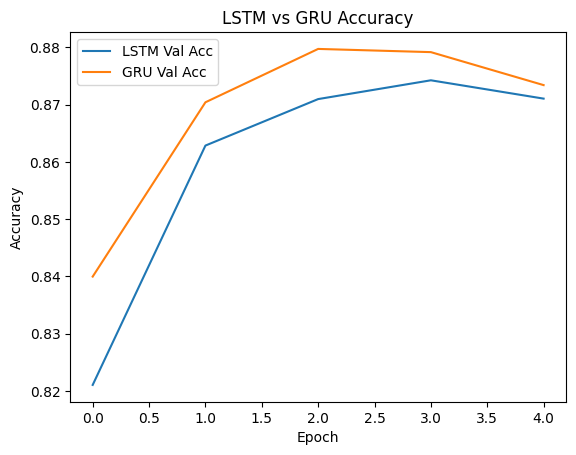

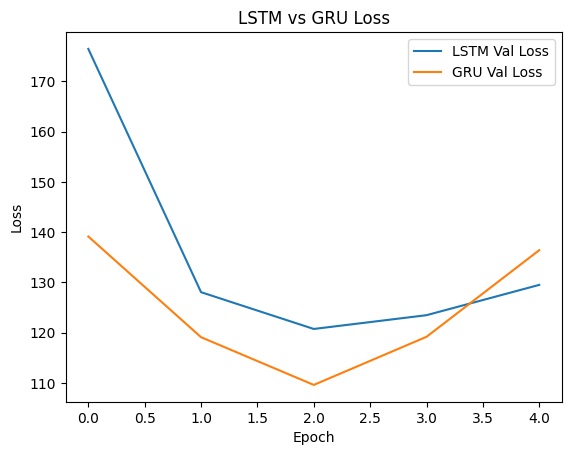

In [16]:
lstm_train_loss, lstm_val_loss, lstm_train_acc, lstm_val_acc = lstm_metrics
gru_train_loss, gru_val_loss, gru_train_acc, gru_val_acc = gru_metrics

# Accuracy
plt.figure()
plt.plot(lstm_val_acc, label="LSTM Val Acc")
plt.plot(gru_val_acc, label="GRU Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM vs GRU Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure()
plt.plot(lstm_val_loss, label="LSTM Val Loss")
plt.plot(gru_val_loss, label="GRU Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM vs GRU Loss")
plt.legend()
plt.show()